In [2]:
# DATASET GENERATION
import pandas as pd
import numpy as np

np.random.seed(42)

n = 10000
data = []

for _ in range(n):

    # -----------------------------
    # Generate base vitals (independent)
    # -----------------------------
    hr = int(np.clip(np.random.normal(90, 20), 50, 160))
    bp = int(np.clip(np.random.normal(120, 20), 70, 180))
    spo2 = int(np.clip(np.random.normal(96, 3), 80, 100))
    pain = np.random.randint(0, 10)
    age = np.random.randint(18, 90)

    # -----------------------------
    # Categorical features (independent base)
    # -----------------------------
    mental = np.random.choice(
        ["Alert", "Verbal", "Pain", "Unresponsive"],
        p=[0.7, 0.15, 0.1, 0.05]
    )

    complaint = np.random.choice([
        "Chest Pain", "Shortness of Breath", "Trauma",
        "Abdominal Pain", "Fever", "Headache"
    ])

    trauma = 1 if complaint == "Trauma" else np.random.choice([0,1], p=[0.85,0.15])

    arrival = np.random.choice(["Walk-in", "Ambulance"], p=[0.7, 0.3])
    chronic = np.random.choice([0,1], p=[0.6, 0.4])

    duration = np.random.choice(
        ["Short", "Medium", "Long"],
        p=[0.4, 0.35, 0.25]
    )

    prev_visits = np.random.randint(0, 6)

    # -----------------------------
    # Derived signals (what model will learn)
    # -----------------------------
    shock_index = hr / (bp + 1)
    oxygen_risk = 100 - spo2

    # -----------------------------
    # Severity score (structured, not deterministic)
    # -----------------------------
    severity = (
        2.2 * (shock_index > 0.9) +
        2.0 * (spo2 < 92) +
        1.5 * (pain > 6) +
        1.2 * (mental in ["Pain", "Unresponsive"]) +
        1.0 * (arrival == "Ambulance") +
        0.8 * chronic +
        0.6 * (duration == "Short") -
        0.5 * (duration == "Long") -
        0.3 * (prev_visits > 3)
    )

    # -----------------------------
    # Controlled noise (IMPORTANT)
    # -----------------------------
    severity += np.random.normal(0, 0.4)

    # -----------------------------
    # Map severity → ESI (overlapping bands)
    # -----------------------------
    if severity > 4.5:
        esi = np.random.choice([1,2], p=[0.6,0.4])
    elif severity > 3:
        esi = np.random.choice([2,3], p=[0.5,0.5])
    elif severity > 2:
        esi = np.random.choice([3,4], p=[0.6,0.4])
    else:
        esi = np.random.choice([4,5], p=[0.5,0.5])

    # -----------------------------
    # Small feature noise (realistic measurement error)
    # -----------------------------
    if np.random.rand() < 0.1:
        hr += np.random.randint(-8, 8)
        bp += np.random.randint(-8, 8)
        spo2 += np.random.randint(-2, 2)

    # -----------------------------
    # Append row
    # -----------------------------
    data.append([
        hr, bp, age, spo2, pain,
        mental, complaint, trauma,
        arrival, chronic, duration, prev_visits,
        esi
    ])

# -----------------------------
# Create DataFrame
# -----------------------------
columns = [
    "Heart_Rate", "Systolic_BP", "Age", "SpO2", "Pain_Score",
    "Mental_Status", "Chief_Complaint", "Trauma",
    "Arrival_Mode", "Chronic_Condition", "Symptom_Duration", "Previous_ER_Visits",
    "ESI_Level"
]

df = pd.DataFrame(data, columns=columns)

# -----------------------------
# Save
# -----------------------------
df.to_csv("ed_triage_structured_4000_v4.csv", index=False)

print("Dataset created: ed_triage_structured_4000_v4.csv")
print(df.head())

Dataset created: ed_triage_structured_4000_v4.csv
   Heart_Rate  Systolic_BP  Age  SpO2  Pain_Score Mental_Status  \
0          99          117   41    97           6         Alert   
1          50          132   72    95           2  Unresponsive   
2          87          119   61    93           6         Alert   
3          80          121   79    95           9          Pain   
4          91          128   88    93           0         Alert   

  Chief_Complaint  Trauma Arrival_Mode  Chronic_Condition Symptom_Duration  \
0           Fever       1    Ambulance                  0            Short   
1      Chest Pain       0      Walk-in                  0            Short   
2          Trauma       1    Ambulance                  0           Medium   
3        Headache       0      Walk-in                  0            Short   
4      Chest Pain       0      Walk-in                  1           Medium   

   Previous_ER_Visits  ESI_Level  
0                   4          5  
1       

In [ ]:
# PERFORMING EXPLANATORY DATA ANALYSIS
import pandas as pd

df = pd.read_csv("ed_triage_structured_4000_v4.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

print("\nData Types:\n")
print(df.dtypes)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nESI Distribution:\n")
print(df["ESI_Level"].value_counts(normalize=True))

print("\nCategorical Values:\n")

print("Mental_Status:", df["Mental_Status"].unique())
print("Chief_Complaint:", df["Chief_Complaint"].unique())
print("Arrival_Mode:", df["Arrival_Mode"].unique())
print("Symptom_Duration:", df["Symptom_Duration"].unique())

print("\nPreview:\n")
print(df.head())

Shape: (10000, 13)

Columns:
 Index(['Heart_Rate', 'Systolic_BP', 'Age', 'SpO2', 'Pain_Score',
       'Mental_Status', 'Chief_Complaint', 'Trauma', 'Arrival_Mode',
       'Chronic_Condition', 'Symptom_Duration', 'Previous_ER_Visits',
       'ESI_Level'],
      dtype='object')

Data Types:

Heart_Rate             int64
Systolic_BP            int64
Age                    int64
SpO2                   int64
Pain_Score             int64
Mental_Status         object
Chief_Complaint       object
Trauma                 int64
Arrival_Mode          object
Chronic_Condition      int64
Symptom_Duration      object
Previous_ER_Visits     int64
ESI_Level              int64
dtype: object

Missing Values:

Heart_Rate            0
Systolic_BP           0
Age                   0
SpO2                  0
Pain_Score            0
Mental_Status         0
Chief_Complaint       0
Trauma                0
Arrival_Mode          0
Chronic_Condition     0
Symptom_Duration      0
Previous_ER_Visits    0
ESI_Level   

In [3]:
#FEATURE ENGINEERING
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv("ed_triage_structured_4000_v4.csv")

# -----------------------------
# Core engineered features
# -----------------------------
df["Shock_Index"] = df["Heart_Rate"] / (df["Systolic_BP"] + 1)
df["Oxygen_Risk"] = 100 - df["SpO2"]
df["Pain_Age"] = df["Pain_Score"] * df["Age"]
df["Pulse_Pressure"] = df["Systolic_BP"] - (0.5 * df["Heart_Rate"])

# -----------------------------
# Binary threshold features
# -----------------------------
df["High_Pain"] = (df["Pain_Score"] >= 7).astype(int)
df["Low_SpO2"] = (df["SpO2"] <= 92).astype(int)
df["Tachycardia"] = (df["Heart_Rate"] >= 100).astype(int)
df["Shock_Flag"] = (df["Shock_Index"] >= 0.9).astype(int)
df["Low_BP"] = (df["Systolic_BP"] <= 90).astype(int)

# -----------------------------
# Interaction features
# -----------------------------
df["Shock_Oxygen"] = df["Shock_Index"] * df["Oxygen_Risk"]
df["HR_Oxygen_Risk"] = df["Heart_Rate"] * df["Oxygen_Risk"]
df["BP_Age"] = df["Systolic_BP"] * df["Age"]
df["Age_Risk"] = df["Age"] * (df["Low_SpO2"] + df["High_Pain"])

df["Critical_Score"] = (
    df["Shock_Flag"] +
    df["Low_SpO2"] +
    df["High_Pain"] +
    df["Tachycardia"] +
    df["Low_BP"]
)

# -----------------------------
# Continuous severity modeling (NEW - important)
# -----------------------------
df["SpO2_Deficit"] = np.maximum(0, 95 - df["SpO2"])
df["BP_Deficit"] = np.maximum(0, 110 - df["Systolic_BP"])
df["HR_Scaled"] = df["Heart_Rate"] / 100

df["Severity_Score"] = (
    3.0 * df["Shock_Index"] +
    2.5 * df["SpO2_Deficit"] +
    1.8 * (df["Pain_Score"] / 10) +
    1.5 * df["HR_Scaled"] +
    1.2 * (df["BP_Deficit"] / 50)
)

df["Log_Shock"] = np.log1p(df["Shock_Index"])

# -----------------------------
# Convert 5-level ESI → 3 classes
# -----------------------------
def map_esi_to_3(x):
    if x == 1:
        return 0   # High
    elif x in [2, 3]:
        return 1   # Medium
    else:
        return 2   # Low

df["ESI_3"] = df["ESI_Level"].apply(map_esi_to_3)

# -----------------------------
# Split features/target
# -----------------------------
X = df.drop(["ESI_Level", "ESI_3"], axis=1)
y = df["ESI_3"]

# -----------------------------
# Encode categorical variables
# -----------------------------
X = pd.get_dummies(
    X,
    columns=[
        "Mental_Status",
        "Chief_Complaint",
        "Arrival_Mode",
        "Symptom_Duration"
    ],
    drop_first=True
)

# -----------------------------
# Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Save datasets
# -----------------------------
X_train.to_csv("X_train_3class.csv", index=False)
X_test.to_csv("X_test_3class.csv", index=False)
y_train.to_csv("y_train_3class.csv", index=False)
y_test.to_csv("y_test_3class.csv", index=False)

print("DONE: Feature Engineering + 3-Class Split")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

DONE: Feature Engineering + 3-Class Split
X_train: (8000, 38)
X_test: (2000, 38)



Training Logistic Regression...

Training Random Forest...

Training AdaBoost...

Training XGBoost...

Model Comparison:
                  Model  Accuracy     MAE
3              XGBoost    0.8110  0.1890
1        Random Forest    0.7980  0.2020
2             AdaBoost    0.7700  0.2300
0  Logistic Regression    0.6895  0.3165

MODEL: Logistic Regression
              precision    recall  f1-score   support

        High       0.35      0.12      0.18        90
      Medium       0.56      0.47      0.51       681
         Low       0.75      0.86      0.80      1229

    accuracy                           0.69      2000
   macro avg       0.56      0.48      0.50      2000
weighted avg       0.67      0.69      0.67      2000



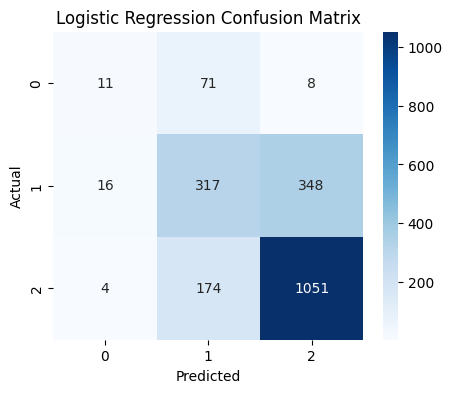


MODEL: Random Forest
              precision    recall  f1-score   support

        High       0.44      0.38      0.40        90
      Medium       0.68      0.77      0.72       681
         Low       0.90      0.85      0.87      1229

    accuracy                           0.80      2000
   macro avg       0.67      0.66      0.67      2000
weighted avg       0.80      0.80      0.80      2000



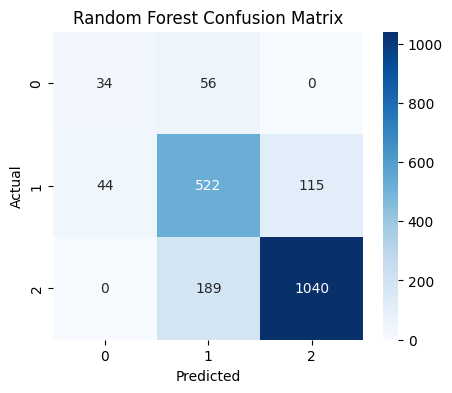


MODEL: AdaBoost
              precision    recall  f1-score   support

        High       0.00      0.00      0.00        90
      Medium       0.67      0.63      0.65       681
         Low       0.81      0.91      0.86      1229

    accuracy                           0.77      2000
   macro avg       0.50      0.51      0.50      2000
weighted avg       0.73      0.77      0.75      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


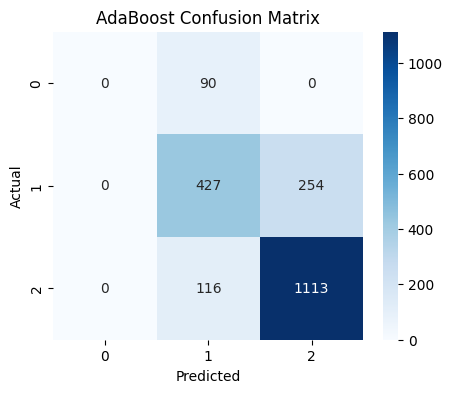


MODEL: XGBoost
              precision    recall  f1-score   support

        High       0.46      0.43      0.45        90
      Medium       0.70      0.78      0.74       681
         Low       0.91      0.86      0.88      1229

    accuracy                           0.81      2000
   macro avg       0.69      0.69      0.69      2000
weighted avg       0.82      0.81      0.81      2000



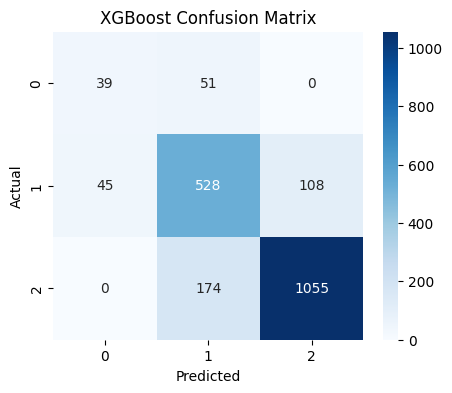


Top Features:
 Log_Shock               0.085577
Shock_Index             0.083020
Critical_Score          0.082095
Age_Risk                0.070212
Severity_Score          0.058797
Pain_Score              0.044963
Shock_Flag              0.044818
Pulse_Pressure          0.043153
Arrival_Mode_Walk-in    0.039399
Shock_Oxygen            0.037747
HR_Oxygen_Risk          0.030688
Chronic_Condition       0.030596
High_Pain               0.029146
Pain_Age                0.027607
BP_Age                  0.024359
dtype: float64


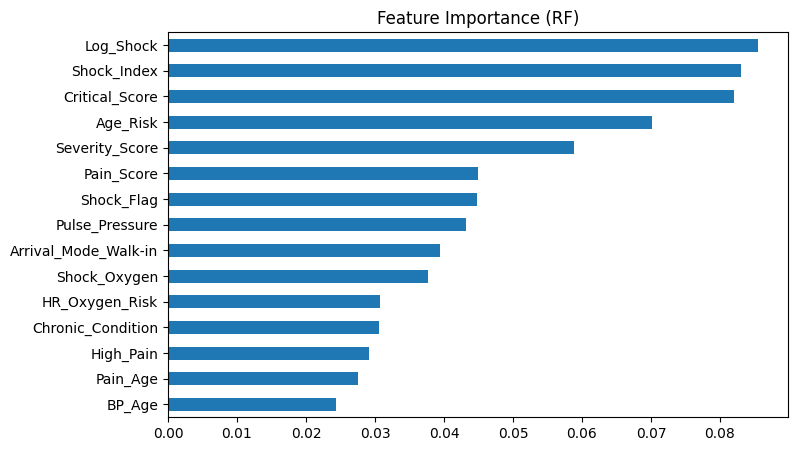

In [4]:
#MODEL TRAINING
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

# -----------------------------------
# Load data (3-class version)
# Use in-memory variables directly to ensure consistency with feature engineering
# -----------------------------------
# X_train = pd.read_csv("X_train_3class.csv") # Removed
# X_test = pd.read_csv("X_test_3class.csv") # Removed
# y_train = pd.read_csv("y_train_3class.csv").squeeze() # Removed
# y_test = pd.read_csv("y_test_3class.csv").squeeze() # Removed

# -----------------------------------
# Class weights (IMPORTANT)
# -----------------------------------
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, weights))
sample_weights = y_train.map(class_weight_dict)

# -----------------------------------
# Models
# -----------------------------------
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        n_jobs=-1
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=14,
        min_samples_split=6,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=700,
        learning_rate=0.04,
        max_depth=6,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=2,
        reg_alpha=0.5,
        min_child_weight=2,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )
}

# -----------------------------------
# Train
# -----------------------------------
trained_models = {}
predictions = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    if name == "XGBoost":
        model.fit(
            X_train, y_train,
            sample_weight=sample_weights,
            eval_set=[(X_test, y_test)],
            verbose=False
        )
    else:
        model.fit(X_train, y_train)

    trained_models[name] = model
    predictions[name] = model.predict(X_test)

# -----------------------------------
# Evaluation
# -----------------------------------
results = []

for name in models:
    acc = accuracy_score(y_test, predictions[name])
    mae = mean_absolute_error(y_test, predictions[name])
    results.append((name, acc, mae))

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "MAE"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print("\nModel Comparison:\n", results_df)

# -----------------------------------
# Reports + Confusion Matrix
# -----------------------------------
labels = ["High", "Medium", "Low"]

for name in models:
    print("\n==============================")
    print(f"MODEL: {name}")
    print("==============================")

    print(classification_report(y_test, predictions[name], target_names=labels))

    cm = confusion_matrix(y_test, predictions[name])
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# -----------------------------------
# Feature Importance (RF)
# -----------------------------------
rf = trained_models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print("\nTop Features:\n", importances.head(15))

plt.figure(figsize=(8,5))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Feature Importance (RF)")
plt.show()

In [ ]:
#MODEL DIAGNOSIS
import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score

# -----------------------------------
# Use trained Random Forest
# -----------------------------------
model = trained_models["Random Forest"]

print("\n==============================")
print("DOMINANCE / LEAKAGE CHECK")
print("==============================")

# -----------------------------------
# 1. Feature Importance Concentration
# -----------------------------------
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

top_feature = importances.index[0]
top_value = importances.iloc[0]
total = importances.sum()

print(f"\nTop Feature: {top_feature}")
print(f"Top Feature Contribution: {top_value:.4f}")
print(f"Top 3 Features Contribution: {importances.head(3).sum():.4f}")

if top_value > 0.25:
    print("⚠️ WARNING: Single feature dominance suspected")
elif importances.head(3).sum() > 0.50:
    print("⚠️ WARNING: Few features dominating model")
else:
    print("✅ No strong dominance detected")

# -----------------------------------
# 2. Permutation Importance (TRUE TEST)
# -----------------------------------
print("\nRunning permutation importance...")

perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_importances = pd.Series(perm.importances_mean, index=X_test.columns)
perm_importances = perm_importances.sort_values(ascending=False)

print("\nTop Permutation Features:\n")
print(perm_importances.head(10))

# -----------------------------------
# 3. Drop-column test (CRITICAL)
# -----------------------------------
print("\nRunning drop-column test...")

baseline_acc = accuracy_score(y_test, model.predict(X_test))
print(f"\nBaseline Accuracy: {baseline_acc:.4f}")

drop_results = []

top_features = importances.head(5).index

for col in top_features:
    X_test_dropped = X_test.drop(columns=[col])
    X_train_dropped = X_train.drop(columns=[col])

    temp_model = model.__class__(**model.get_params())
    temp_model.fit(X_train_dropped, y_train)

    acc = accuracy_score(y_test, temp_model.predict(X_test_dropped))

    drop_results.append((col, baseline_acc - acc))

drop_df = pd.DataFrame(drop_results, columns=["Feature", "Accuracy Drop"])
drop_df = drop_df.sort_values(by="Accuracy Drop", ascending=False)

print("\nDrop Column Impact:\n")
print(drop_df)

# -----------------------------------
# 4. Correlation with Target (Leakage hint)
# -----------------------------------
print("\nChecking correlation with target...")

df_corr = X_train.copy()
df_corr["target"] = y_train

corrs = df_corr.corr()["target"].abs().sort_values(ascending=False)

print("\nTop correlations with target:\n")
print(corrs.head(10))

if corrs.iloc[1] > 0.7:
    print("\n⚠️ VERY HIGH correlation detected → possible leakage")
else:
    print("\n✅ No obvious leakage via correlation")

# -----------------------------------
# Final verdict
# -----------------------------------
print("\n==============================")
print("FINAL DIAGNOSIS")
print("==============================")

if baseline_acc > 0.85:
    print("⚠️ Accuracy too high for this dataset → likely leakage or synthetic bias")
else:
    print("✅ Accuracy within realistic bounds")

print("\nInspect:")
print("- Top feature importance")
print("- Drop impact")
print("- Correlation spikes")


DOMINANCE / LEAKAGE CHECK

Top Feature: Log_Shock
Top Feature Contribution: 0.0856
Top 3 Features Contribution: 0.2507
✅ No strong dominance detected

Running permutation importance...

Top Permutation Features:

Arrival_Mode_Walk-in          0.0271
Symptom_Duration_Short        0.0153
Mental_Status_Pain            0.0115
Chronic_Condition             0.0096
Age_Risk                      0.0052
Pain_Score                    0.0044
High_Pain                     0.0035
BP_Age                        0.0028
Mental_Status_Unresponsive    0.0026
Symptom_Duration_Medium       0.0025
dtype: float64

Running drop-column test...

Baseline Accuracy: 0.7980

Drop Column Impact:

          Feature  Accuracy Drop
1     Shock_Index         0.0055
0       Log_Shock         0.0050
2  Critical_Score         0.0030
3        Age_Risk         0.0015
4  Severity_Score         0.0005

Checking correlation with target...

Top correlations with target:

target            1.000000
Critical_Score    0.619080
Sh

In [1]:
#MULTI LOOP SIMULATION
import random
import pandas as pd
import copy
import numpy as np

# ----------------------------
# Simulation Parameters
# ----------------------------
NUM_PATIENTS = 650
TIME_STEPS = 24 * 60
ALPHA = 0.5
BETA = 2
UNIT_DURATION = 15

TRIAGE_DISTRIBUTION = {
    "level_1": 0.10,
    "level_2": 0.30,
    "level_3": 0.60
}

# ----------------------------
# Resources
# ----------------------------
resource_template = {
    "ICU_beds": 4,
    "normal_beds": 15,
    "doctors": 8
}

# ----------------------------
# Arrival Pattern
# ----------------------------
def generate_arrival():
    if random.random() < 0.8:
        return random.randint(10*60, 20*60)
    else:
        return random.randint(0, TIME_STEPS-1)

# ----------------------------
# Severity Mapping
# ----------------------------
def severity_score(esi):
    if esi == 1:
        return 3
    elif esi == 3:
        return 2
    else:
        return 1

# ----------------------------
# Patient Generation
# ----------------------------
def generate_patients():
    patients = []
    num_l1 = int(NUM_PATIENTS * TRIAGE_DISTRIBUTION["level_1"])
    num_l2 = int(NUM_PATIENTS * TRIAGE_DISTRIBUTION["level_2"])
    num_l3 = NUM_PATIENTS - num_l1 - num_l2

    pid = 0

    for _ in range(num_l1):
        t_time = int(3 * UNIT_DURATION * random.uniform(0.8, 1.2))
        patients.append({
            "id": pid, "arrival_time": generate_arrival(), "ESI": 1,
            "waiting_time": 0, "treatment_time": t_time, "needs_icu": True,
            "start_time": None, "end_time": None
        })
        pid += 1

    for _ in range(num_l2):
        t_time = int(2 * UNIT_DURATION * random.uniform(0.8, 1.2))
        needs_icu = random.random() < 0.1
        patients.append({
            "id": pid, "arrival_time": generate_arrival(), "ESI": 3,
            "waiting_time": 0, "treatment_time": t_time, "needs_icu": needs_icu,
            "start_time": None, "end_time": None
        })
        pid += 1

    for _ in range(num_l3):
        t_time = int(1 * UNIT_DURATION * random.uniform(0.8, 1.2))
        patients.append({
            "id": pid, "arrival_time": generate_arrival(), "ESI": 5,
            "waiting_time": 0, "treatment_time": t_time, "needs_icu": False,
            "start_time": None, "end_time": None
        })
        pid += 1

    patients.sort(key=lambda x: x["arrival_time"])
    return patients

# ----------------------------
# Simulation
# ----------------------------
def run_simulation(patients, scheduler_type="priority"):
    patients = copy.deepcopy(patients)
    resources = copy.deepcopy(resource_template)
    active_patients = []

    waiting_times = []
    critical_wait_times = []

    icu_used_time = 0
    normal_used_time = 0
    doctor_used_time = 0
    throughput = 0

    for t in range(TIME_STEPS):

        queue = [p for p in patients if p["arrival_time"] <= t and p["start_time"] is None]

        for p in queue:
            p["waiting_time"] = t - p["arrival_time"]

        # Scheduling
        if scheduler_type == "priority":
            for p in queue:
                sev = severity_score(p["ESI"])

                base_priority = (
                    BETA * sev +
                    ALPHA * np.log1p(p["waiting_time"])
                )

                # Selective WSPT
                if p["ESI"] == 1:
                    p["priority"] = base_priority
                else:
                    p["priority"] = base_priority / p["treatment_time"]

                # Critical early boost
                if p["ESI"] == 1 and p["waiting_time"] < 10:
                    p["priority"] += 3

                # ICU encouragement
                if p["needs_icu"]:
                    p["priority"] += 1

                # Starvation prevention
                if p["waiting_time"] > 30:
                    p["priority"] += 2
                if p["waiting_time"] > 60:
                    p["priority"] += 3

            queue.sort(key=lambda x: x["priority"], reverse=True)

        else:
            queue.sort(key=lambda x: x["arrival_time"])

        # Allocation
        for p in queue:
            if p["start_time"] is not None:
                continue

            if p["needs_icu"]:
                if resources["ICU_beds"] > 0 and resources["doctors"] > 0:
                    resources["ICU_beds"] -= 1
                    resources["doctors"] -= 1
                    p["start_time"] = t
                    p["end_time"] = t + p["treatment_time"]
                    active_patients.append(p)
            else:
                if resources["normal_beds"] > 0 and resources["doctors"] > 0:
                    resources["normal_beds"] -= 1
                    resources["doctors"] -= 1
                    p["start_time"] = t
                    p["end_time"] = t + p["treatment_time"]
                    active_patients.append(p)

        # Utilization tracking
        icu_used_time += (resource_template["ICU_beds"] - resources["ICU_beds"])
        normal_used_time += (resource_template["normal_beds"] - resources["normal_beds"])
        doctor_used_time += (resource_template["doctors"] - resources["doctors"])

        # Release
        finished = [p for p in active_patients if p["end_time"] <= t]

        for p in finished:
            if p["needs_icu"]:
                resources["ICU_beds"] += 1
            else:
                resources["normal_beds"] += 1

            resources["doctors"] += 1
            active_patients.remove(p)

            waiting_times.append(p["waiting_time"])
            throughput += 1

            if p["ESI"] == 1:
                critical_wait_times.append(p["waiting_time"])

    critical_wait_times = np.array(critical_wait_times)

    metrics = {
        "Avg Waiting Time (all)": np.mean(waiting_times),
        "Avg Waiting Time (Critical)": np.mean(critical_wait_times),
        "95th Percentile (all)": np.percentile(waiting_times, 95),
        "95th Percentile (Critical)": np.percentile(critical_wait_times, 95),
        "Critical >30min (%)": np.mean(critical_wait_times > 30) * 100,
        "Critical >60min (%)": np.mean(critical_wait_times > 60) * 100,
        "ICU Efficiency": icu_used_time / (resource_template["ICU_beds"] * TIME_STEPS),
        "Doctor Utilization": doctor_used_time / (resource_template["doctors"] * TIME_STEPS),
        "Throughput per hour": throughput / 24
    }

    return metrics

# ----------------------------
# Multi-run Simulation
# ----------------------------
def run_multiple_simulations(n_runs=30):
    priority_results = []
    fcfs_results = []

    for i in range(n_runs):
        random.seed(i)
        np.random.seed(i)

        patients = generate_patients()

        priority_results.append(run_simulation(patients, "priority"))
        fcfs_results.append(run_simulation(patients, "fcfs"))

    return priority_results, fcfs_results

# ----------------------------
# Aggregation
# ----------------------------
def aggregate_results(results_list):
    df = pd.DataFrame(results_list)
    return pd.DataFrame({
        "Metric": df.columns,
        "Mean": df.mean().values,
        "Std Dev": df.std().values
    })

# ----------------------------
# Run Experiment
# ----------------------------
priority_runs, fcfs_runs = run_multiple_simulations(30)

priority_summary = aggregate_results(priority_runs)
fcfs_summary = aggregate_results(fcfs_runs)

comparison = priority_summary.copy()
comparison["FCFS Mean"] = fcfs_summary["Mean"]
comparison["FCFS Std Dev"] = fcfs_summary["Std Dev"]

print(comparison)

                        Metric        Mean    Std Dev   FCFS Mean  \
0       Avg Waiting Time (all)  115.438524  10.691318  215.738196   
1  Avg Waiting Time (Critical)   43.834315  16.110892  204.067826   
2        95th Percentile (all)  439.523333  53.764701  488.761667   
3   95th Percentile (Critical)   93.286667  23.974519  463.090000   
4          Critical >30min (%)   56.797873  15.461195   77.233919   
5          Critical >60min (%)   38.322815  20.561611   72.294488   
6               ICU Efficiency    0.606285   0.019530    0.334022   
7           Doctor Utilization    0.687436   0.017028    0.687436   
8          Throughput per hour   15.006944   0.391799   14.168056   

   FCFS Std Dev  
0     11.508010  
1     28.775793  
2     15.377630  
3     28.862305  
4      6.600526  
5      7.076597  
6      0.028463  
7      0.017028  
8      0.386940  
